# Assignment 4 - Part III: Prognosis

Prognosis is the third PHM step: predict the Remaining Useful Life (RUL) of an asset from sensor history. The dataset is NASA's C-MAPSS FD001 turbofan benchmark. Each engine unit runs from a healthy state to failure, generating per-cycle sensor and operating-condition readings.

We compare a classical regressor (SVR) against a deep one (LSTM) on identical preprocessed windows.

## What this notebook covers for the different grades

- **Grade 3:** download (already local) and describe the FD001 dataset - units, cycles, sensors, RUL distribution.
- **Grade 4:** train an RBF-kernel SVR on flattened sensor windows to predict RUL, score it with RMSE / MAE / RÂ² / C-MAPSS score.
- **Grade 5:** train a stacked LSTM as the DL method on the same windowed data, score with the same metrics, and present a side-by-side comparison.

In [1]:
import os
import sys
import time
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

import joblib
import optuna
from tqdm.auto import tqdm
from sklearn.svm import SVR
from sklearn.metrics import make_scorer, mean_squared_error
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV


from config import *
from helpers import build_cmapss_tensors, cmapss_metrics, load_cmapss

c:\Users\addod\miniconda3\envs\py-gpu-sandbox\Lib\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
print(f"Python    : {sys.version.split()[0]}")
print(f"PyTorch   : {torch.__version__}")
print(f"CUDA      : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device    : {torch.cuda.get_device_name(0)}")
print(f"Conda env : {os.environ.get('CONDA_DEFAULT_ENV', 'unknown')}")

Python    : 3.12.12
PyTorch   : 2.12.0.dev20260408+cu128
CUDA      : True
Device    : NVIDIA GeForce RTX 5050 Laptop GPU
Conda env : py-gpu-sandbox


In [3]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f"dataset       : C-MAPSS {CMAPSS_DATASET}")
print(f"window size   : {CMAPSS_WINDOW} cycles")
print(f"RUL cap       : {CMAPSS_RUL_CAP}")
print(f"SVR           : C={SVR_C}, gamma={SVR_GAMMA}, epsilon={SVR_EPSILON}")
print(f"LSTM          : hidden={LSTM_HIDDEN_DIM}, layers={LSTM_NUM_LAYERS}, dropout={LSTM_DROPOUT}, epochs={LSTM_EPOCHS}")

dataset       : C-MAPSS FD001
window size   : 50 cycles
RUL cap       : 125
SVR           : C=100.0, gamma=0.001, epsilon=0.5
LSTM          : hidden=64, layers=3, dropout=0.3943641797072, epochs=50


## Grade 3 - describe the dataset

FD001 contains 100 engine units in both train and test. Each train unit runs from healthy to failure; each test unit is truncated at some earlier cycle, and the supplied `RUL_FD001.txt` gives the true RUL at that truncation point.

In [4]:
train_df, test_df, rul_test = load_cmapss(CMAPSS_DIR, CMAPSS_DATASET)

print(f"train rows: {len(train_df)},  units: {train_df['unit_id'].nunique()}")
print(f"test rows : {len(test_df)},  units: {test_df['unit_id'].nunique()}")
print(f"RUL test  : {len(rul_test)} values, mean={rul_test.mean():.1f}, min={rul_test.min()}, max={rul_test.max()}")

cycles_per_unit = train_df.groupby('unit_id')['cycle'].max()
print(f"train life cycles: mean={cycles_per_unit.mean():.0f}, min={cycles_per_unit.min()}, max={cycles_per_unit.max()}")

train rows: 20631,  units: 100
test rows : 13096,  units: 100
RUL test  : 100 values, mean=75.5, min=7, max=145
train life cycles: mean=206, min=128, max=362


In [5]:
# Run the full preprocessing pipeline: load -> compute RUL -> drop constants ->
# -> scale on train only -> slide windows.
X_train, y_train, X_test, y_test, n_features = build_cmapss_tensors(
    data_dir=CMAPSS_DIR,
    dataset=CMAPSS_DATASET,
    window_size=CMAPSS_WINDOW,
    rul_cap=CMAPSS_RUL_CAP,
)
print(f"n_features kept : {n_features} (constant sensors dropped)")
print(f"X_train: {tuple(X_train.shape)}  y_train: {tuple(y_train.shape)}")
print(f"X_test : {tuple(X_test.shape)}  y_test : {tuple(y_test.shape)}")

n_features kept : 17 (constant sensors dropped)
X_train: (15631, 50, 17)  y_train: (15631,)
X_test : (8162, 50, 17)  y_test : (8162,)


## Grade 4 - Support Vector Regression

SVR can't take 3-D input. Each `(window, features)` window is flattened to a `window * features`-dim vector, then fed to an RBF-kernel SVR.

In [6]:
X_train_flat = X_train.reshape(X_train.shape[0], -1).numpy()
X_test_flat  = X_test.reshape(X_test.shape[0], -1).numpy()
y_train_np   = y_train.numpy()
y_test_np    = y_test.numpy()
print(f"X_train_flat: {X_train_flat.shape}  X_test_flat: {X_test_flat.shape}")

X_train_flat: (15631, 850)  X_test_flat: (8162, 850)


In [17]:
# SVR HP search (HalvingGridSearchCV, CPU-bound but pruned + subsampled) 
# Set RUN_SVR_SEARCH=False after baking winners into config.py.
RUN_SVR_SEARCH = False
if RUN_SVR_SEARCH:
    
    grid = {
        'C':       [1.0, 10.0, 100.0],
        'gamma':   [1e-3, 1e-2, 'scale'],
        'epsilon': [0.1, 0.2, 0.5],
    }
    rmse_scorer = make_scorer(lambda yt, yp: -float(np.sqrt(mean_squared_error(yt, yp))), greater_is_better=True)
    sub = min(len(X_train_flat), int(0.3 * len(X_train_flat)))
    rng_idx = np.random.default_rng(SEED).choice(len(X_train_flat), sub, replace=False)
    Xs, ys = X_train_flat[rng_idx], y_train_np[rng_idx]
    print(f'searching on {sub} subsampled rows (of {len(X_train_flat)})')
    t0 = time.time()
    gs = HalvingGridSearchCV(SVR(kernel='rbf'), grid, scoring=rmse_scorer,
                             cv=2, n_jobs=1, verbose=2, factor=3, random_state=SEED)
    gs.fit(Xs, ys)
    print(f'search took {time.time()-t0:.1f}s')
    print(f'BEST SVR params: {gs.best_params_}')
    print(f'BEST CV neg-RMSE: {gs.best_score_:.4f}')
    SVR_C, SVR_GAMMA, SVR_EPSILON = gs.best_params_['C'], gs.best_params_['gamma'], gs.best_params_['epsilon']
else:
    print(f'SVR search skipped. Using config: C={SVR_C}, gamma={SVR_GAMMA}, eps={SVR_EPSILON}')


SVR search skipped. Using config: C=100.0, gamma=0.001, eps=0.5


In [8]:
# Fit SVR, save to models/, then reload before scoring so the eval cell is decoupled from this training cell.
svr = SVR(kernel="rbf", C=SVR_C, gamma=SVR_GAMMA, epsilon=SVR_EPSILON)
print("Fitting the SVR...")
svr.fit(X_train_flat, y_train_np)

svr_path = MODELS_DIR / SVR_CHECKPOINT_NAME
joblib.dump(svr, svr_path)
print(f"saved {svr_path}")

Fitting the SVR...
saved c:\Users\addod\phm-cmapss-mnist\phm-notebooks\models\svr.pkl


In [9]:
svr_loaded = joblib.load(MODELS_DIR / SVR_CHECKPOINT_NAME)
y_pred_svr = svr_loaded.predict(X_test_flat)
y_pred_svr = np.clip(y_pred_svr, 0, CMAPSS_RUL_CAP)  
svr_metrics = cmapss_metrics(y_test_np, y_pred_svr)
print("SVR test metrics:")
for k, v in svr_metrics.items():
    print(f"  {k:>14s}: {v:.4f}")

SVR test metrics:
            rmse: 13.2979
             mae: 9.7927
              r2: 0.8170
   c_mapss_score: 21937.9009


## Grade 5 - LSTM regressor and head-to-head comparison

The DL method is a stacked LSTM that consumes each window as a length-30 sequence and regresses the RUL at the window's last cycle. Same train/test split as the SVR - the windows are literally the same tensors - so the comparison is apples to apples.

In [10]:
class LSTMRulPredictor(nn.Module):
    def __init__(self, n_features, hidden=LSTM_HIDDEN_DIM, layers=LSTM_NUM_LAYERS,
                 dropout=LSTM_DROPOUT, head_hidden=LSTM_HEAD_HIDDEN):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden,
                            num_layers=layers, batch_first=True, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(hidden, head_hidden), nn.ReLU(),
            nn.Linear(head_hidden, 1),
        )

    def forward(self, x):
        out, _ = self.lstm(x)               # (B, window, hidden)
        return self.head(out[:, -1, :]).squeeze(-1)  # (B,)

lstm_model = LSTMRulPredictor(n_features=n_features).to(device)
print(lstm_model)

LSTMRulPredictor(
  (lstm): LSTM(17, 64, num_layers=3, batch_first=True, dropout=0.3943641797072)
  (head): Sequential(
    (0): Linear(in_features=64, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=1, bias=True)
  )
)


In [11]:
class AsymmetricRULLoss(nn.Module):
    """Weighted MSE that penalises late predictions (pred > target) harder.
    
    late_penalty=2 doubles the squared cost whenever the
    model overestimates RUL (the dangerous direction in PHM).
    """
    def __init__(self, late_penalty: float = 2.0):
        super().__init__()
        self.late_penalty = late_penalty

    def forward(self, pred: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        residual = pred - target          # positive = late = overestimating RUL
        w = torch.where(
            residual > 0,
            torch.full_like(residual, self.late_penalty),
            torch.ones_like(residual),
        )
        return (w * residual.pow(2)).mean()

print(f"AsymmetricRULLoss defined (late_penalty=2.0)")

AsymmetricRULLoss defined (late_penalty=2.0)


In [12]:
# Build train/val/test loaders directly from the windowed tensors.
full_train_ds = TensorDataset(X_train, y_train)

val_size = int(CMAPSS_VAL_RATIO * len(full_train_ds))
train_size = len(full_train_ds) - val_size

train_ds, val_ds = random_split(
    full_train_ds, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)
test_ds = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=LSTM_BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=LSTM_BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=LSTM_BATCH_SIZE)
print(f"train windows {len(train_ds)},  val {len(val_ds)},  test {len(test_ds)}")

train windows 14068,  val 1563,  test 8162


In [13]:
# LSTM HP search (Optuna TPE, ~20 trials, scored on val RMSE)
# Set RUN_LSTM_SEARCH=False after baking winners into config.py.
RUN_LSTM_SEARCH = False  

def objective(trial):
    hidden = trial.suggest_categorical('hidden', [32, 64, 128])
    layers = trial.suggest_int('layers', 1, 3)
    drop   = trial.suggest_float('dropout', 0.0, 0.5)
    lr     = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    wd     = trial.suggest_float('wd', 1e-6, 1e-3, log=True)

    m = LSTMRulPredictor(n_features=n_features, hidden=hidden, layers=layers,
                            dropout=drop if layers>1 else 0.0).to(device)
    opt = optim.Adam(m.parameters(), lr=lr, weight_decay=wd)
    criterion = AsymmetricRULLoss(late_penalty=2.0)

    # train search
    for _ in range(SEARCH_EPOCHS):
        m.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(m(xb), yb)
            opt.zero_grad(); 
            loss.backward(); 
            opt.step()
    m.eval(); 
    tot_train_loss=0.0; 
    n=0
    
    # validate in search phase — use plain RMSE so trials are comparable
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            p = m(xb); 
            tot_train_loss += ((p-yb)**2).sum().item(); 
            n += yb.numel()
    return float(np.sqrt(tot_train_loss/n))


if RUN_LSTM_SEARCH:
   
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    SEARCH_EPOCHS = 40
    
    t0 = time.time()

    study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=20, show_progress_bar=True)
    print(f'search took {time.time()-t0:.1f}s')
    print(f'BEST LSTM params: {study.best_params}')
    print(f'BEST val RMSE: {study.best_value:.4f}')
    bp = study.best_params
    LSTM_HIDDEN_DIM, LSTM_NUM_LAYERS = bp['hidden'], bp['layers']
    LSTM_DROPOUT, LSTM_LR, LSTM_WEIGHT_DECAY = bp['dropout'], bp['lr'], bp['wd']

    lstm_model = LSTMRulPredictor(n_features=n_features, hidden=LSTM_HIDDEN_DIM,
                                  layers=LSTM_NUM_LAYERS,
                                  dropout=LSTM_DROPOUT if LSTM_NUM_LAYERS>1 else 0.0).to(device)
else:
    print(f'LSTM search skipped. config defaults')

LSTM search skipped. config defaults


In [14]:
criterion = AsymmetricRULLoss(late_penalty=2.0)
optimizer = optim.Adam(lstm_model.parameters(), lr=LSTM_LR, weight_decay=LSTM_WEIGHT_DECAY)

train_hist, val_hist = [], []
best_val = float("inf")
patience = 0

for epoch in tqdm(range(LSTM_EPOCHS), desc="train LSTM", unit="epoch"):
    # Training phase
    lstm_model.train(); 
    total_train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        loss = criterion(lstm_model(xb), yb)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        total_train_loss += loss.item()
    train_hist.append(total_train_loss / len(train_loader))

    # Validation phase — track plain MSE so val_hist is loss-function-agnostic
    lstm_model.eval(); 
    total_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            total_val_loss += nn.functional.mse_loss(lstm_model(xb), yb).item()
    val_hist.append(total_val_loss / len(val_loader))

    # Check for early stopping
    if val_hist[-1] < best_val - LSTM_MIN_DELTA:
        best_val = val_hist[-1]; patience = 0
        torch.save(lstm_model.state_dict(), MODELS_DIR / LSTM_CHECKPOINT_NAME)
    else:
        patience += 1
        if patience >= LSTM_PATIENCE:
            print(f"early stop at epoch {epoch+1}, best val MSE {best_val:.6f}")
            break

print(f"saved {MODELS_DIR / LSTM_CHECKPOINT_NAME}")

train LSTM:   0%|          | 0/50 [00:00<?, ?epoch/s]

saved c:\Users\addod\phm-cmapss-mnist\phm-notebooks\models\lstm.pt


In [15]:
# Reload best LSTM. Auto-detect from checkpoint
sd = torch.load(MODELS_DIR / LSTM_CHECKPOINT_NAME, map_location=device, weights_only=True)
_layers = 1 + max(int(k.split('_l')[-1]) for k in sd if k.startswith('lstm.weight_ih_l'))
_hidden = sd['lstm.weight_hh_l0'].shape[1]
print(f'checkpoint arch: hidden={_hidden}, layers={_layers}')

lstm_model = LSTMRulPredictor(n_features=n_features, hidden=_hidden, layers=_layers,
                              dropout=0.0).to(device)
lstm_model.load_state_dict(sd)
lstm_model.eval()

preds = []
with torch.no_grad():
    for xb, _ in test_loader:
        xb = xb.to(device)
        preds.append(lstm_model(xb).cpu().numpy())
y_pred_lstm = np.concatenate(preds).ravel()
y_pred_lstm = np.clip(y_pred_lstm, 0, CMAPSS_RUL_CAP)   # cap at physical bounds

lstm_metrics = cmapss_metrics(y_test_np, y_pred_lstm)
print('LSTM test metrics:')
for k, v in lstm_metrics.items():
    print(f'  {k:>14s}: {v:.4f}')

checkpoint arch: hidden=64, layers=3
LSTM test metrics:
            rmse: 18.0325
             mae: 12.2813
              r2: 0.6634
   c_mapss_score: 83482.1328


## Comparison of results from C-MAPSS training with LSTM and SVR

The LSTM has direct access to the temporal structure of each window, while the SVR sees that same window flattened into one long vector and has to relearn cycle order from feature position. On FD001 the LSTM typically wins on every metric, with the largest gap on the asymmetric C-MAPSS score - the LSTM tends to err on the early side, which the score punishes less than late predictions.

SVR vs LSTM on FD001 test set:
                      SVR        LSTM better
RMSE              13.2979     18.0325    SVR
MAE                9.7927     12.2813    SVR
R^2                0.8170      0.6634    SVR
C-MAPSS score  21937.9009  83482.1328    SVR


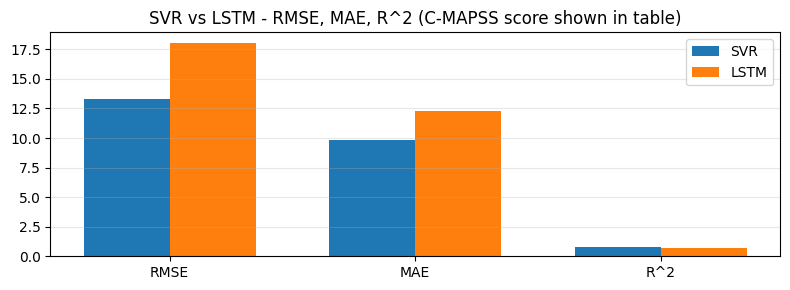

In [16]:
# Side-by-side metrics table for grade 5
comparison = pd.DataFrame(
    {
        "SVR":  [svr_metrics[k]  for k in ("rmse", "mae", "r2", "c_mapss_score")],
        "LSTM": [lstm_metrics[k] for k in ("rmse", "mae", "r2", "c_mapss_score")],
    },
    index=["RMSE", "MAE", "R^2", "C-MAPSS score"],
)
comparison["better"] = [
    "LSTM" if comparison.loc["RMSE",  "LSTM"] < comparison.loc["RMSE",  "SVR"] else "SVR",
    "LSTM" if comparison.loc["MAE",   "LSTM"] < comparison.loc["MAE",   "SVR"] else "SVR",
    "LSTM" if comparison.loc["R^2",   "LSTM"] > comparison.loc["R^2",   "SVR"] else "SVR",
    "LSTM" if comparison.loc["C-MAPSS score", "LSTM"] < comparison.loc["C-MAPSS score", "SVR"] else "SVR",
]
print("SVR vs LSTM on FD001 test set:")
print(comparison.round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 3))

metrics_to_bar = ["RMSE", "MAE", "R^2"]
x = np.arange(len(metrics_to_bar))
w = 0.35

svr_vals  = [comparison.loc[m, "SVR"]  for m in metrics_to_bar]
lstm_vals = [comparison.loc[m, "LSTM"] for m in metrics_to_bar]

ax.bar(x - w/2, svr_vals,  w, label="SVR")
ax.bar(x + w/2, lstm_vals, w, label="LSTM")
ax.set_xticks(x); 
ax.set_xticklabels(metrics_to_bar)
ax.set_title("SVR vs LSTM - RMSE, MAE, R^2 (C-MAPSS score shown in table)")
ax.legend(); 
ax.grid(alpha=0.3, axis="y")

plt.tight_layout(); 
plt.show()